In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import numpy as np
import sklearn

In [2]:
# import the dataset
with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)
df = pd.read_csv(config["input_data"]["file_1"])

In [3]:
# check quickly data content
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)
print(df.select_dtypes("str").nunique().sort_values(ascending=False))

(2111, 17)
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
Gender                                str
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight        str
FAVC                                  str
FCVC                              float64
NCP                               float64
CAEC                        

In [5]:
# drop duplicates
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(2087, 17)

In [19]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035
std,6.368801,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [8]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


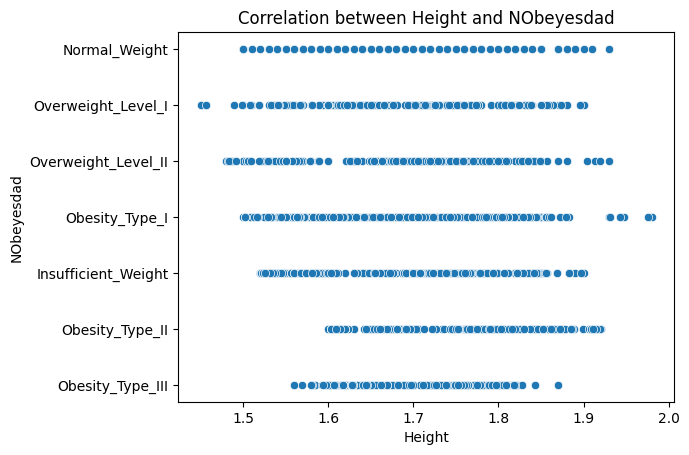

In [9]:
#check the correlation between height and NObeyesdad
sns.scatterplot(x="Height", y="NObeyesdad", data=df)
plt.title("Correlation between Height and NObeyesdad")
plt.show()

In [10]:
# the correlation is not very strong, but there is a slight positive correlation between height and NObeyesdad. This means that as height increases, the likelihood of being classified as NObeyesdad also increases, but the relationship is not very strong.

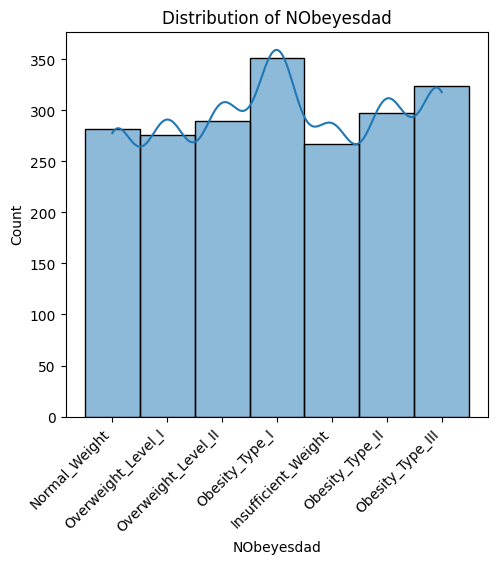

In [17]:
# check the distribution of the target variable NObeyesdad
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(x="NObeyesdad", data=df, kde=True)
plt.title("Distribution of NObeyesdad")
plt.xticks(rotation=45, ha="right") 
plt.show()

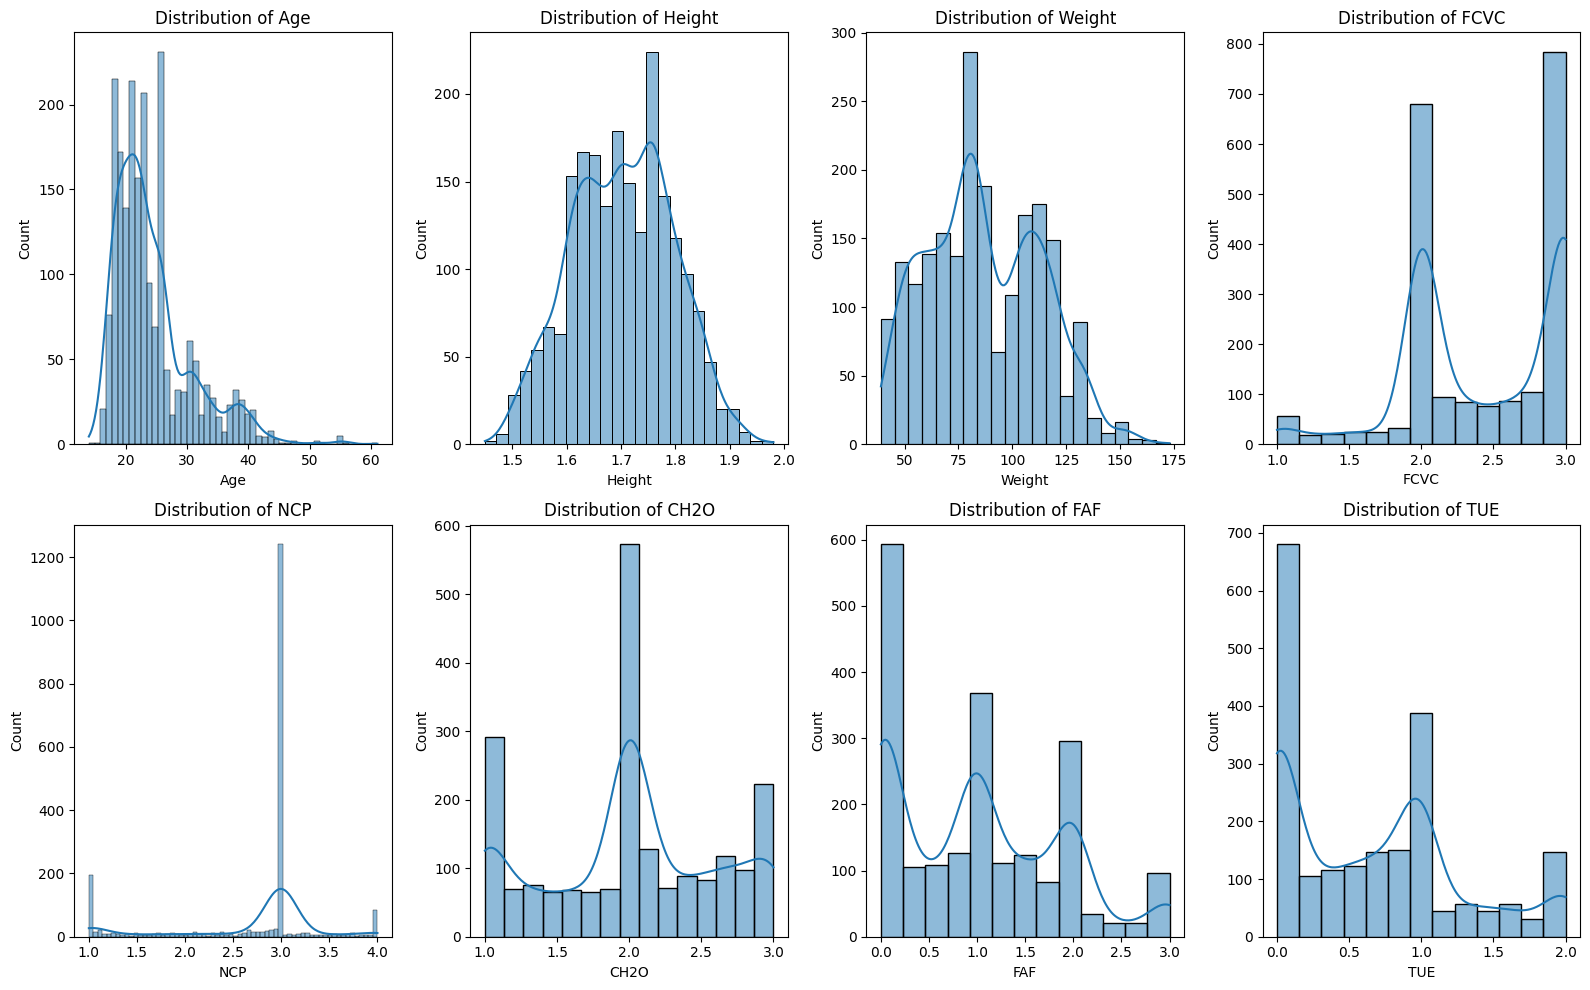

In [20]:
numeric_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i + 1)
    sns.histplot(x=col, data=df, kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

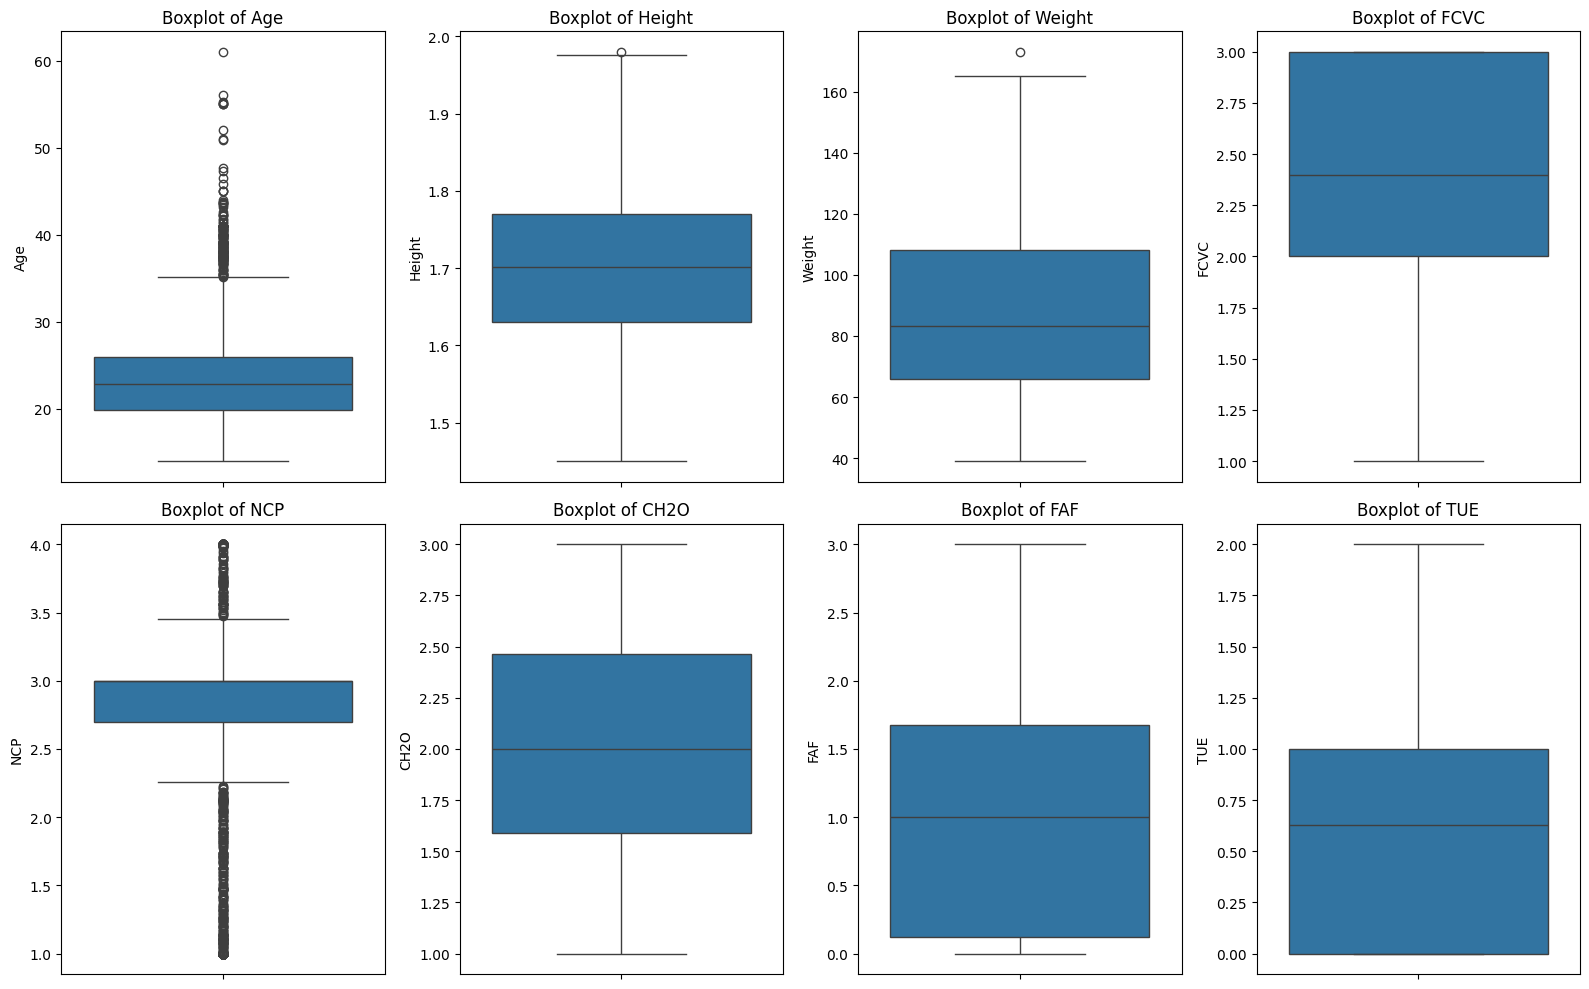

In [21]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(y=col, data=df)
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

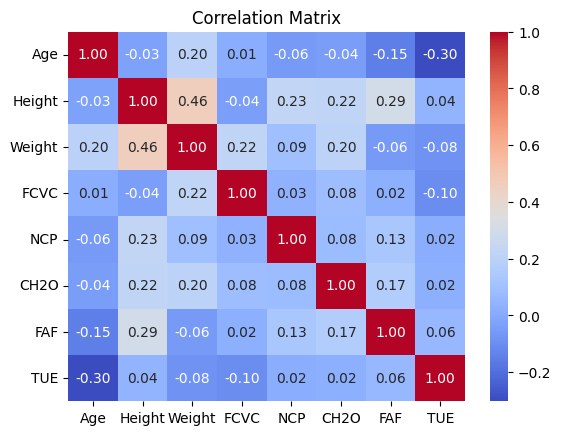

In [22]:
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()